# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/codingsheep17/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
#initializing the repo
import os

if not os.path.exists("flyrank-ml-internship"):
    !git clone https://github.com/codingsheep17/flyrank-ml-internship.git

os.chdir("flyrank-ml-internship")
print(os.getcwd())

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 253, done.
remote: Counting objects: 100% (253/253), done.
remote: Compressing objects: 100% (209/209), done.
remote: Total 253 (delta 130), reused 94 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (253/253), 2.52 MiB | 9.71 MiB/s, done.
Resolving deltas: 100% (130/130), done.
/content/flyrank-ml-internship


In [2]:
#installing the dataset
!pip install duckdb huggingface_hub -q

from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
print("Token loaded:", "HF_TOKEN" in os.environ)

Token loaded: True


In [3]:
import duckdb

con = duckdb.connect()
con.sql(f"""
CREATE SECRET hf_token (
    TYPE huggingface,
    TOKEN '{os.environ["HF_TOKEN"]}'
);
""")
print("DuckDB secret configured")

DuckDB secret configured


## 1. Question

*The research question and the decision it supports.*

Among visible pages, which ones are most likely to lose search visibility in the following month, and can a simple model rank them better than a hand-written staleness-and-CTR rule?

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Release: FlyRank ML Internship warehouse (FlyRank/internship-warehouse on Hugging Face), queried with DuckDB.

Tables: fact_content_daily_performance (daily search metrics) joined with dim_content (page metadata).

Windows: Features come from Feb 2026. The label comes from Mar 2026. June 2026 stays sealed as the final test month.

Excluded: rows without search data (gsc_data_available IS TRUE only), pages under 100 impressions in Feb, and pages whose recorded update date is after 28 Feb (to avoid using future information). GA4 fields are excluded because coverage is sparse.

Public-safe: only hashed IDs and aggregated numbers are used. There are no client names, URLs or queries.

In [4]:
cap_df = con.sql("""
WITH feb AS (
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_impressions) AS imp,
        SUM(gsc_clicks) AS clicks,
        AVG(gsc_avg_position) AS pos,
        COUNT(*) FILTER (WHERE gsc_impressions > 0) AS days_visible
    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet'
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
),
mar AS (
    SELECT
        content_hash_id,
        SUM(gsc_impressions) AS imp_next
    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id
)
SELECT
    feb.*,
    mar.imp_next,
    d.word_count,
    d.content_type,
    DATE_DIFF('day', d.content_updated_date, DATE '2026-02-28') AS days_stale,
    DATE_DIFF('day', d.content_created_date, DATE '2026-02-28') AS age_days,
    CASE WHEN mar.imp_next < 0.7 * feb.imp THEN 1 ELSE 0 END AS label_declined
FROM feb
JOIN mar USING (content_hash_id)
JOIN 'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet' d USING (content_hash_id)
WHERE feb.imp >= 100
  AND d.content_updated_date <= DATE '2026-02-28'
""").df()

print("Shape:", cap_df.shape)
print(cap_df["label_declined"].value_counts(normalize=True))
cap_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Shape: (16632, 12)
label_declined
0    0.8364
1    0.1636
Name: proportion, dtype: float64


,content_hash_id,client_hash_id,imp,clicks,pos,days_visible,imp_next,word_count,content_type,days_stale,age_days,label_declined
0,content_787913b76bdb6d3d,client_23a62021009f63c4,129.0,0.0,8.773724,28,81.0,5141,keyword article,3,128,1
1,content_694a23b322c406a0,client_23a62021009f63c4,1002.0,7.0,10.186791,28,745.0,6352,keyword article,3,128,0
2,content_05942874fc960a6c,client_23a62021009f63c4,2074.0,4.0,32.821792,28,4870.0,6602,keyword article,3,128,0
3,content_582b3ab8d4fcfa9e,client_23a62021009f63c4,2152.0,1.0,13.988213,28,3312.0,6371,keyword article,3,128,0
4,content_a3d02a0e46e0f5f1,client_23a62021009f63c4,141.0,0.0,13.738846,28,153.0,5007,keyword article,3,128,0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Assumptions: Pages with at least 100 impressions in Feb have enough signal to judge a change. A page "declined" if its Mar impressions fell below 70% of its Feb impressions.

Features (all from Feb or earlier): impressions, clicks, CTR, average position, days visible, word count, days since last update, page age, content type.

Label: label_declined = 1 if Mar impressions < 70% of Feb impressions. It is built only from the future window (Mar).

Baseline: a hand-written rule ranking pages higher when they are stale and have low CTR compared with pages at a similar position. It uses no labels and no model.

Validation: client-holdout split. All pages from one client go entirely into train or test, so the model is tested on clients it has never seen.

Leakage checks: no March data in the features, no product flags, and no update date after the feature window ends.

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

df = cap_df.copy()

# Features
df["ctr"] = (df["clicks"] / df["imp"]).fillna(0)
df["position_bucket"] = pd.cut(df["pos"], bins=[0, 3, 10, 20, 1000],
                               labels=["top_3", "page_1", "page_2", "deep"])
df = pd.get_dummies(df, columns=["content_type"], dtype=int)

# Baseline rule (no labels, no model): stale + low CTR vs pages at a similar position
stale_pct = df["days_stale"].rank(pct=True)
ctr_pct = df.groupby("position_bucket", observed=True)["ctr"].rank(pct=True)
df["baseline_score"] = 0.5 * stale_pct + 0.5 * (1 - ctr_pct)

feature_cols = ["imp", "clicks", "ctr", "pos", "days_visible",
                "word_count", "days_stale", "age_days"] + \
               [c for c in df.columns if c.startswith("content_type_")]

# Client-holdout split
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(df, df["label_declined"], groups=df["client_hash_id"]))
train, test = df.iloc[train_idx], df.iloc[test_idx]

print(f"Train: {len(train)} pages, {train['client_hash_id'].nunique()} clients, decline rate {train['label_declined'].mean():.3f}")
print(f"Test:  {len(test)} pages, {test['client_hash_id'].nunique()} clients, decline rate {test['label_declined'].mean():.3f}")
print("Client overlap:", len(set(train['client_hash_id']) & set(test['client_hash_id'])))

Train: 8710 pages, 18 clients, decline rate 0.169
Test:  7922 pages, 9 clients, decline rate 0.157
Client overlap: 0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In this slice, a random forest did not beat a simple stale-plus-low-CTR rule, and both showed only weak page-level signal (observed, directional).

Method	ROC AUC	Precision@50	Precision@100
Baseline rule (stale + low CTR)	0.582	0.50	0.38
Random forest v1 (raw features)	0.566	0.10	0.13
Random forest v2 (client-relative features)	0.489	0.06	0.13

Why Table A is misleading: one client makes up 91% of the test pages. The baseline's top 50 was 32 pages from a single client whose decline rate (31%) is about double the average. Staleness is constant within a client, so the rule ranked clients, not pages.

Table B: within-client ranking, out-of-fold (8 clients with 100+ pages)

Method	Mean AUC	Clients above chance
Baseline rule	0.556	7 of 8
Random forest	0.550	7 of 8

Reading it: both methods sit only slightly above chance (0.5) and are effectively tied. Any ranking skill is small, and the rule's within-client skill comes only from its CTR component.

In [6]:
import json, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

X_train = train[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = test[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y_train = train["label_declined"].values
y_test = test["label_declined"].values

rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
test = test.copy()
test["model_score"] = rf.predict_proba(X_test)[:, 1]

def precision_at_k(y, scores, k):
    top = np.argsort(-scores)[:k]
    return y[top].mean()

rows = []
for name, scores in [("Baseline rule (stale + low CTR)", test["baseline_score"].values),
                     ("Random forest", test["model_score"].values)]:
    rows.append({
        "Method": name,
        "ROC AUC": roc_auc_score(y_test, scores),
        "Avg precision": average_precision_score(y_test, scores),
        "Precision@50": precision_at_k(y_test, scores, 50),
        "Precision@100": precision_at_k(y_test, scores, 100),
    })
results = pd.DataFrame(rows).round(3)
print(f"Base rate (share of test pages that declined): {y_test.mean():.3f}")
print(results.to_string(index=False))

os.makedirs("work/outputs", exist_ok=True)
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump({"base_rate": float(y_test.mean()), "results": results.to_dict(orient="records")}, f, indent=2)

Base rate (share of test pages that declined): 0.157
                         Method  ROC AUC  Avg precision  Precision@50  Precision@100
Baseline rule (stale + low CTR)    0.582          0.203           0.5           0.38
                  Random forest    0.566          0.191           0.1           0.13


In [7]:
# Diagnostic: are age_days / days_stale basically client-level constants?
chk = df.groupby("client_hash_id")[["age_days", "days_stale"]].nunique()
print("Median distinct values per client:")
print(chk.median(), "\n")

# Client-relative features: rank of each page within its own client
df2 = df.copy()
for c in ["imp", "clicks", "ctr", "pos", "days_visible", "word_count"]:
    df2[c + "_rel"] = df2.groupby("client_hash_id")[c].rank(pct=True)
rel_cols = [c for c in df2.columns if c.endswith("_rel")]

train2, test2 = df2.iloc[train_idx], df2.iloc[test_idx].copy()
rf2 = RandomForestClassifier(
    n_estimators=300, max_depth=6, min_samples_leaf=50,
    class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
rf2.fit(train2[rel_cols].fillna(0), train2["label_declined"].values)
test2["model2_score"] = rf2.predict_proba(test2[rel_cols].fillna(0))[:, 1]

rows2 = []
for name, scores in [("Baseline rule (stale + low CTR)", test2["baseline_score"].values),
                     ("Random forest v1 (raw features)", test["model_score"].values),
                     ("Random forest v2 (client-relative features)", test2["model2_score"].values)]:
    rows2.append({
        "Method": name,
        "ROC AUC": roc_auc_score(y_test, scores),
        "Avg precision": average_precision_score(y_test, scores),
        "Precision@50": precision_at_k(y_test, scores, 50),
        "Precision@100": precision_at_k(y_test, scores, 100),
    })
results2 = pd.DataFrame(rows2).round(3)
print(f"Base rate: {y_test.mean():.3f}")
print(results2.to_string(index=False))

with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump({"base_rate": float(y_test.mean()), "results": results2.to_dict(orient="records")}, f, indent=2)

Median distinct values per client:
age_days      2.0
days_stale    1.0
dtype: float64 

Base rate: 0.157
                                     Method  ROC AUC  Avg precision  Precision@50  Precision@100
            Baseline rule (stale + low CTR)    0.582          0.203          0.50           0.38
            Random forest v1 (raw features)    0.566          0.191          0.10           0.13
Random forest v2 (client-relative features)    0.489          0.152          0.06           0.13


In [9]:
t = test2.copy()
t["model_score"] = test["model_score"].values
t["y"] = y_test

# 1) Where do each method's top-50 picks come from?
for name, col in [("Baseline rule", "baseline_score"), ("Random forest v1", "model_score")]:
    top = t.nlargest(50, col)
    print(f"{name}: top-50 comes from {top['client_hash_id'].nunique()} client(s), hit rate {top['y'].mean():.2f}")
    print(top.groupby("client_hash_id")["y"].agg(["count", "mean"]).round(2).to_string(), "\n")

# 2) Decline rate and size for each test client
by_client = (t.groupby("client_hash_id")["y"]
               .agg(pages="count", decline_rate="mean")
               .round(3).sort_values("pages", ascending=False))
print(by_client.to_string())

Baseline rule: top-50 comes from 4 client(s), hit rate 0.54
                         count  mean
client_hash_id                      
client_3f0ce4d44fe94f3d      1  0.00
client_65de48885f4ef01b     32  0.78
client_73cda7b4e4f265ea     10  0.20
client_a80fca3f171ed1de      7  0.00 

Random forest v1: top-50 comes from 3 client(s), hit rate 0.10
                         count  mean
client_hash_id                      
client_65de48885f4ef01b      2  0.50
client_73cda7b4e4f265ea     47  0.06
client_795153d5b7850ccf      1  1.00 

                         pages  decline_rate
client_hash_id                              
client_73cda7b4e4f265ea   7218         0.141
client_65de48885f4ef01b    597         0.313
client_795153d5b7850ccf     60         0.550
client_d211cb07b9059bab     14         0.214
client_0797ff3a1fc9a6a5     12         0.333
client_a2eeb8899886adde      8         0.250
client_a80fca3f171ed1de      7         0.000
client_3ffa76342f366962      4         0.000
client_3f0ce4d44

In [10]:
from sklearn.model_selection import GroupKFold

d = df.copy()
d["y"] = d["label_declined"].values
X_all = d[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# Out-of-fold predictions: every page is scored by a model that never saw its client
oof = np.zeros(len(d))
for tr, te in GroupKFold(n_splits=5).split(X_all, d["y"], groups=d["client_hash_id"]):
    m = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=20,
                               class_weight="balanced_subsample", random_state=42, n_jobs=-1)
    m.fit(X_all.iloc[tr], d["y"].iloc[tr])
    oof[te] = m.predict_proba(X_all.iloc[te])[:, 1]
d["rf_oof"] = oof

# Within-client ranking skill: ROC AUC per client (0.5 = chance)
rows = []
for cid, g in d.groupby("client_hash_id"):
    pos = g["y"].sum()
    if len(g) >= 100 and pos >= 10 and (len(g) - pos) >= 10:
        rows.append({
            "client": f"Client {chr(65 + len(rows))}",
            "pages": len(g),
            "decline_rate": round(g["y"].mean(), 3),
            "baseline_AUC": round(roc_auc_score(g["y"], g["baseline_score"]), 3),
            "rf_AUC": round(roc_auc_score(g["y"], g["rf_oof"]), 3),
        })
within = pd.DataFrame(rows)
print(within.to_string(index=False))
print("\nMean within-client AUC:", within[["baseline_AUC", "rf_AUC"]].mean().round(3).to_dict())

  client  pages  decline_rate  baseline_AUC  rf_AUC
Client A    192         0.422         0.539   0.472
Client B   5764         0.175         0.608   0.521
Client C    715         0.178         0.581   0.622
Client D    742         0.135         0.504   0.563
Client E    597         0.313         0.657   0.509
Client F   7218         0.141         0.576   0.531
Client G    181         0.320         0.556   0.630
Client H    819         0.087         0.431   0.549

Mean within-client AUC: {'baseline_AUC': 0.556, 'rf_AUC': 0.55}


## 5. Limitations

*What this work cannot claim.*

What this work cannot claim

Weak signal. Within-client ROC AUC is about 0.55 for both methods, barely above chance. These rankings are decision-support hints, not reliable predictions.
The label is a proxy. "Declined" means March impressions fell below 70% of February's. That can reflect seasonality, consolidation with another page, or tracking noise, not only a real decline.
Survivorship bias. The dataset keeps only pages that appear in both months. Pages that lost all visibility in March are dropped, so the most extreme declines are missing.
Staleness is a client-level number. dim_content stores each page's latest update date, so days_stale is the same for every page in a client. It ranks clients, not pages.
Concentrated data. One client holds about 44% of all pages, and only 8 clients had enough pages for the within-client analysis. Results may not carry over to other clients.
One window pair. Features come from Feb 2026 and the label from Mar 2026, so there is no check across other months. The sealed June 2026 test month was not used.
No GA4 or query-level features. GA4 coverage is sparse and query-level data was not used.
Observational only. Nothing here shows that refreshing a page causes recovery, and nothing here says how Google's ranking works.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The blend's mean within-client AUC is 0.566, against 0.556 for the baseline and 0.549 for the forest. That gain is about 0.01 across 8 clients, which is inside the noise, so I'd treat it as "no worse than either signal alone."
The queue's decline rate is 23.4%, against 16.4% overall. That is about 1.4x. The comparison is fair because the queue takes the top 10% within each client, so it can't win by picking a risky client. The pages inside one client are correlated, so the real uncertainty is wider than the raw counts suggest.
The blend weights (50/50) were fixed before any results, not tuned on labels. That's why the queue's lift isn't a selection artifact, and the paper should say so.
79% of the queue (1,327 pages) is model_flagged_risk. That is the default bucket for "ranked high, no specific diagnosis." The paper should say so plainly.

In [11]:
# 1) Does blending the two weak signals help? Same within-client AUC test as before.
d["blend"] = 0.5 * d["baseline_score"].rank(pct=True) + 0.5 * d["rf_oof"].rank(pct=True)

def mean_within_auc(col):
    aucs = []
    for cid, g in d.groupby("client_hash_id"):
        pos = g["y"].sum()
        if len(g) >= 100 and pos >= 10 and (len(g) - pos) >= 10:
            aucs.append(roc_auc_score(g["y"], g[col]))
    return np.mean(aucs)

for col in ["baseline_score", "rf_oof", "blend"]:
    print(f"{col}: mean within-client AUC = {mean_within_auc(col):.3f}")

# 2) Review queue: top 10% of pages inside each client
d["client_pct"] = d.groupby("client_hash_id")["blend"].rank(pct=True)
d["ctr_pct"] = d.groupby("position_bucket", observed=True)["ctr"].rank(pct=True)
imp_q75 = d["imp"].quantile(0.75)

def reason_and_action(r):
    if r["ctr_pct"] <= 0.25 and r["imp"] >= imp_q75:
        return "high_visibility_low_ctr", "Review title and meta description"
    if r["pos"] > 20:
        return "deep_position", "Review content depth and intent match"
    if r["days_visible"] < 20:
        return "patchy_visibility", "Monitor; check for consolidation or indexing"
    return "model_flagged_risk", "Monitor and review at next refresh cycle"

queue = d[d["client_pct"] >= 0.90].copy()
queue[["reason_code", "action"]] = queue.apply(lambda r: pd.Series(reason_and_action(r)), axis=1)
queue = queue.sort_values("imp", ascending=False).reset_index(drop=True)
queue["rank"] = queue.index + 1

print(f"\nQueue size: {len(queue)} pages")
print(f"Share of queue that actually declined: {queue['y'].mean():.3f}  (overall base rate: {d['y'].mean():.3f})")
print(queue["reason_code"].value_counts().to_string())

cols = ["rank", "content_hash_id", "imp", "pos", "reason_code", "action"]
os.makedirs("work/outputs", exist_ok=True)
queue[cols].to_csv("work/outputs/ranked_recommendations.csv", index=False)
queue[cols].head(10)

baseline_score: mean within-client AUC = 0.556
rf_oof: mean within-client AUC = 0.549
blend: mean within-client AUC = 0.566

Queue size: 1679 pages
Share of queue that actually declined: 0.234  (overall base rate: 0.164)
reason_code
model_flagged_risk         1327
patchy_visibility           188
high_visibility_low_ctr      84
deep_position                80


,rank,content_hash_id,imp,pos,reason_code,action
0,1,content_66d1fffc91f4f029,12294.0,12.028832,patchy_visibility,Monitor; check for consolidation or indexing
1,2,content_4b3ab5ebb70090f1,10622.0,2.313798,high_visibility_low_ctr,Review title and meta description
2,3,content_bc15b2472b88cd59,6947.0,4.400559,high_visibility_low_ctr,Review title and meta description
3,4,content_177ff38316792bcc,6368.0,1.273867,high_visibility_low_ctr,Review title and meta description
4,5,content_eaccd7441ee37d02,6124.0,5.720684,model_flagged_risk,Monitor and review at next refresh cycle
5,6,content_4981cb34b411063e,5922.0,13.435545,patchy_visibility,Monitor; check for consolidation or indexing
6,7,content_f8deb900838273f8,5620.0,2.527787,high_visibility_low_ctr,Review title and meta description
7,8,content_75e0d8f4c4198185,5302.0,9.100405,high_visibility_low_ctr,Review title and meta description
8,9,content_6f3c6055c21669c6,4809.0,4.803825,high_visibility_low_ctr,Review title and meta description
9,10,content_e952ff791cd1e23e,4619.0,8.968657,high_visibility_low_ctr,Review title and meta description


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Artifacts the paper embeds (saved to work/outputs/figures/, with key numbers in paper_numbers.json):

Figure 1: within-client ranking skill (ROC AUC) for the baseline, forest and blend, against the chance line at 0.5.
Figure 2: client concentration, showing that a few clients hold most of the pages.
Figure 3: decline rate in the review queue, overall and by reason code.

Reading the per-reason rates carefully: high_visibility_low_ctr shows the highest decline rate (44%), but it covers only 84 pages, likely from a small number of clients, so it is a lead to test, not a finding. deep_position declined at about the overall rate (17.5%), so this data gives no support for that action.

Run the cell.

Did the three charts show up, and did capstone_figures.zip download? Keep that zip, because the paper page will use those images.

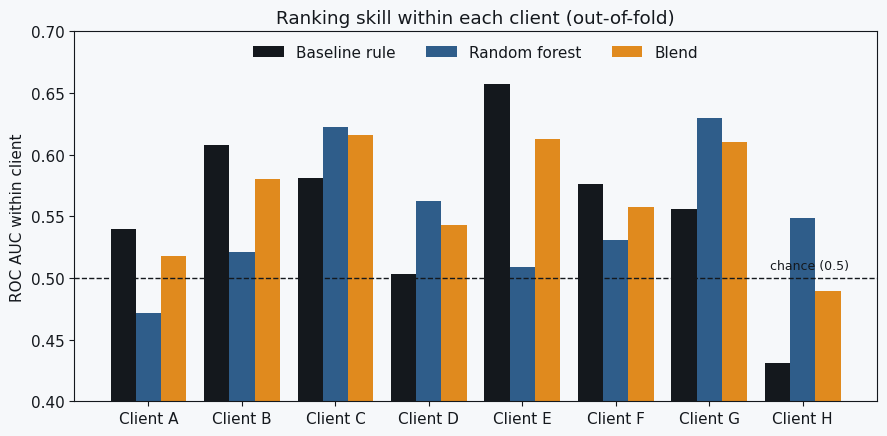

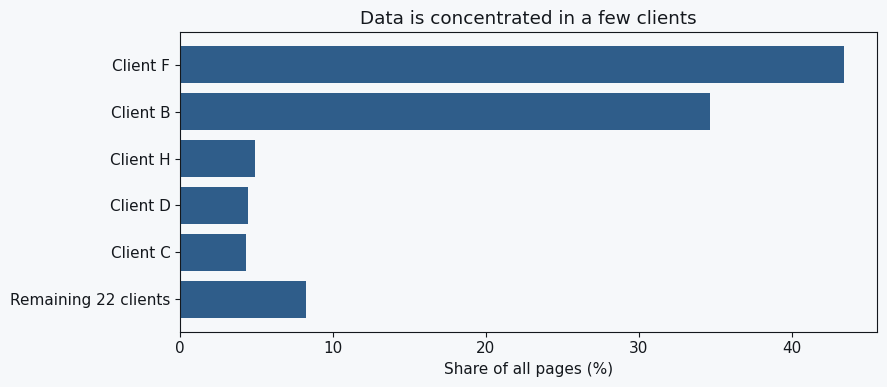

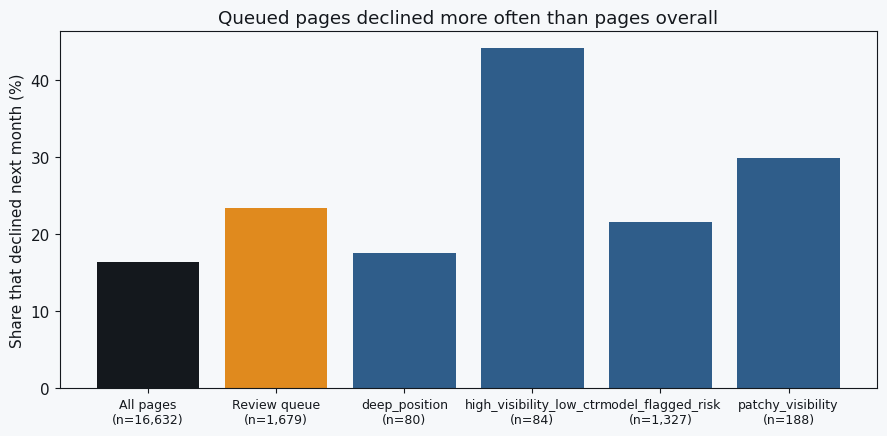

{
  "pages": 16632,
  "clients": 27,
  "base_rate": 0.164,
  "within_client_auc": {
    "baseline": 0.556,
    "forest": 0.549,
    "blend": 0.566
  },
  "queue_size": 1679,
  "queue_decline_rate": 0.234,
  "queue_by_reason": {
    "deep_position": {
      "pages": 80,
      "decline_rate": 0.175
    },
    "high_visibility_low_ctr": {
      "pages": 84,
      "decline_rate": 0.44
    },
    "model_flagged_risk": {
      "pages": 1327,
      "decline_rate": 0.216
    },
    "patchy_visibility": {
      "pages": 188,
      "decline_rate": 0.298
    }
  }
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import matplotlib.pyplot as plt
import json, os, shutil

BLUE, AMBER, INK, BG = "#2F5D8A", "#E08A1E", "#14181D", "#F6F8FA"
os.makedirs("work/outputs/figures", exist_ok=True)
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "axes.edgecolor": INK,
    "text.color": INK, "axes.labelcolor": INK, "xtick.color": INK,
    "ytick.color": INK, "font.size": 11,
})

# Within-client table (now including the blend), with stable anonymous labels
rows, letter = [], {}
for cid, g in d.groupby("client_hash_id"):
    pos = g["y"].sum()
    if len(g) >= 100 and pos >= 10 and (len(g) - pos) >= 10:
        name = f"Client {chr(65 + len(rows))}"
        letter[cid] = name
        rows.append({
            "client": name, "pages": len(g),
            "baseline": roc_auc_score(g["y"], g["baseline_score"]),
            "forest": roc_auc_score(g["y"], g["rf_oof"]),
            "blend": roc_auc_score(g["y"], g["blend"]),
        })
w = pd.DataFrame(rows)

# Figure 1: within-client ranking skill
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(w)); bw = 0.27
ax.bar(x - bw, w["baseline"], bw, label="Baseline rule", color=INK)
ax.bar(x, w["forest"], bw, label="Random forest", color=BLUE)
ax.bar(x + bw, w["blend"], bw, label="Blend", color=AMBER)
ax.axhline(0.5, color=INK, linestyle="--", linewidth=1)
ax.text(len(w) - 0.5, 0.505, "chance (0.5)", ha="right", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(w["client"])
ax.set_ylim(0.4, 0.7); ax.set_ylabel("ROC AUC within client")
ax.set_title("Ranking skill within each client (out-of-fold)")
ax.legend(frameon=False, ncol=3, loc="upper center")
plt.tight_layout(); plt.savefig("work/outputs/figures/fig1_within_client_auc.png", dpi=200); plt.show()

# Figure 2: client concentration
counts = d.groupby("client_hash_id").size().sort_values(ascending=False)
top = counts.head(5)
labels = [letter.get(c, "Other client") for c in top.index]
rest = counts.iloc[5:].sum()
vals = list(top.values / counts.sum() * 100) + [rest / counts.sum() * 100]
labels = labels + [f"Remaining {len(counts) - 5} clients"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(labels[::-1], vals[::-1], color=BLUE)
ax.set_xlabel("Share of all pages (%)")
ax.set_title("Data is concentrated in a few clients")
plt.tight_layout(); plt.savefig("work/outputs/figures/fig2_client_concentration.png", dpi=200); plt.show()

# Figure 3: decline rate in the review queue
groups = [("All pages", d["y"].mean(), len(d)), ("Review queue", queue["y"].mean(), len(queue))]
for code, g in queue.groupby("reason_code"):
    groups.append((code, g["y"].mean(), len(g)))
names = [f"{n}\n(n={c:,})" for n, _, c in groups]
rates = [r * 100 for _, r, _ in groups]
colors = [INK, AMBER] + [BLUE] * (len(groups) - 2)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(names, rates, color=colors)
ax.set_ylabel("Share that declined next month (%)")
ax.set_title("Queued pages declined more often than pages overall")
plt.xticks(fontsize=9)
plt.tight_layout(); plt.savefig("work/outputs/figures/fig3_queue_decline_rate.png", dpi=200); plt.show()

# Key numbers for the paper
summary = {
    "pages": int(len(d)), "clients": int(d["client_hash_id"].nunique()),
    "base_rate": round(float(d["y"].mean()), 3),
    "within_client_auc": {k: round(float(w[k].mean()), 3) for k in ["baseline", "forest", "blend"]},
    "queue_size": int(len(queue)), "queue_decline_rate": round(float(queue["y"].mean()), 3),
    "queue_by_reason": {n: {"pages": int(c), "decline_rate": round(float(r), 3)} for n, r, c in groups[2:]},
}
with open("work/outputs/paper_numbers.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

# Zip the figures + numbers so you can download them (Colab storage is temporary)
shutil.copy("work/outputs/paper_numbers.json", "work/outputs/figures/paper_numbers.json")
shutil.make_archive("capstone_figures", "zip", "work/outputs/figures")
from google.colab import files
files.download("capstone_figures.zip")

Closing: demo outline, social-post cut, employer summary

5-minute demo outline

0:00-0:30, the question. Which pages are most likely to lose search visibility next month, and does a model beat a simple rule at ranking them?
0:30-1:30, the data and the label. FlyRank's anonymized warehouse, Feb 2026 features, and a "declined" label from Mar 2026, so no future information leaks into the features.
1:30-2:30, the first result and why it was misleading. One holdout split showed the rule winning, but 91% of the test pages came from a single client.
2:30-3:30, the fairer test. Ranking within each client gives AUC of about 0.55 for both methods, barely above chance.
3:30-4:30, the review queue and the playbook. The top 10% within each client declined 23.4% of the time, against 16.4% overall, with actions by reason code.
4:30-5:00, the honest limits. Weak signal, a proxy label, and two clients holding 78% of the pages.

Social-post cut
I built a model to predict which web pages will lose search visibility next month. It didn't beat a simple rule. The bigger lesson was that my first result looked good only because one client made up 91% of the test set. Ranking within each client showed the signal is weak. I published the real numbers anyway.

Employer-facing summary (3 sentences)
I built and validated a page-level decline-risk ranking on real, anonymized search data, using a leakage-safe design with client-holdout and out-of-fold evaluation. I found that the headline metric was inflated by one dominant client, corrected it with within-client testing, and reported the modest result honestly (AUC about 0.55) instead of tuning until it looked good. The output is a ranked review queue with reason codes, where queued pages declined about 1.4x as often as pages overall.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
